# Tarea 4 — Red de una sola neurona con y sin PCA

Curso: Inteligencia Artificial II

Profesor: Dr. Andrés Hernández Gutiérrez

Fecha de entrega: Jueves 5 de marzo de 2026, 11:59 pm

Integrantes:
- Jesús Leonardo Tamez 587400
- Ignacio Gaxiola 656752
- Cesar Del Rio — 634582

En este notebook se implementa un modelo de clasificación binaria basado en una sola neurona para el dataset de Breast Cancer Wisconsin. El dataset pertenece al dominio médico y contiene 569 muestras con 30 características numéricas extraídas de imágenes digitalizadas de aspirados de masa mamaria. La variable objetivo indica si el tumor es maligno o benigno.

El objetivo es diseñar, entrenar y evaluar el modelo con todas las features originales, y después aplicar PCA para reducir la dimensionalidad y comparar ambos enfoques en términos de rendimiento y estabilidad.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
# Cargar dataset de cancer de mama
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target  # 0 = maligno, 1 = benigno

print(f"Dimensiones: {df.shape}")
print(f"  0 → {data.target_names[0]} (maligno)")
print(f"  1 → {data.target_names[1]} (benigno)")
df.head()

Dimensiones: (569, 31)
  0 → malignant (maligno)
  1 → benign (benigno)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cargamos el dataset de Breast Cancer de sklearn. Tiene 569 muestras con 30 características numéricas de células tumorales y una etiqueta que dice si es maligno o benigno.

In [ ]:
# Checar datos faltantes y duplicados
print("Valores faltantes:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("\nTipos de datos:")
print(df.dtypes.value_counts())

Valores faltantes: 0
Filas duplicadas: 0

Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64


Revisamos que no haya valores faltantes ni filas duplicadas. Si todo sale limpio podemos seguir sin hacer imputación ni nada extra.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Vemos un resumen general de las features: media, desviación estándar, mínimos y máximos para darnos una idea de las escalas y rangos de cada variable.

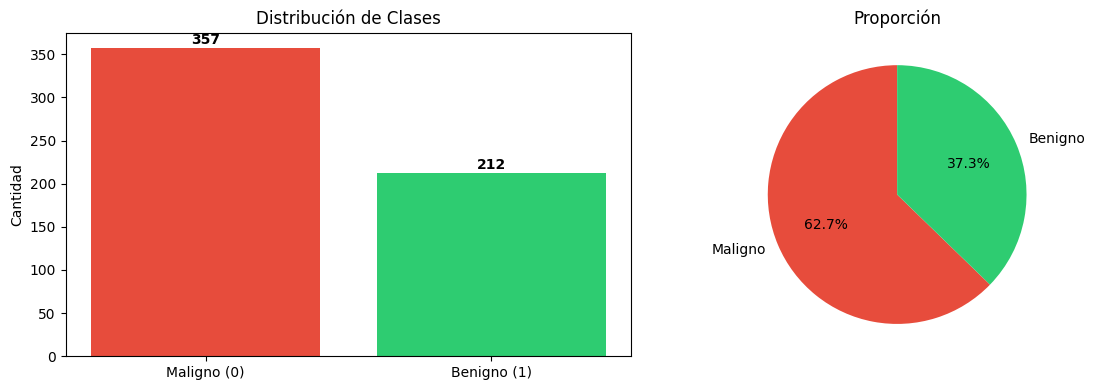

Maligno: 212 (37.3%)
Benigno: 357 (62.7%)


In [ ]:
# Distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo = df['diagnosis'].value_counts()

axes[0].bar(['Maligno (0)', 'Benigno (1)'], conteo.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución de Clases')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Maligno', 'Benigno'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

print(f"Maligno: {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)")
print(f"Benigno: {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)")

Checamos qué tan balanceado está el dataset. Si hay muchas más muestras de una clase que de otra podría afectar al modelo.

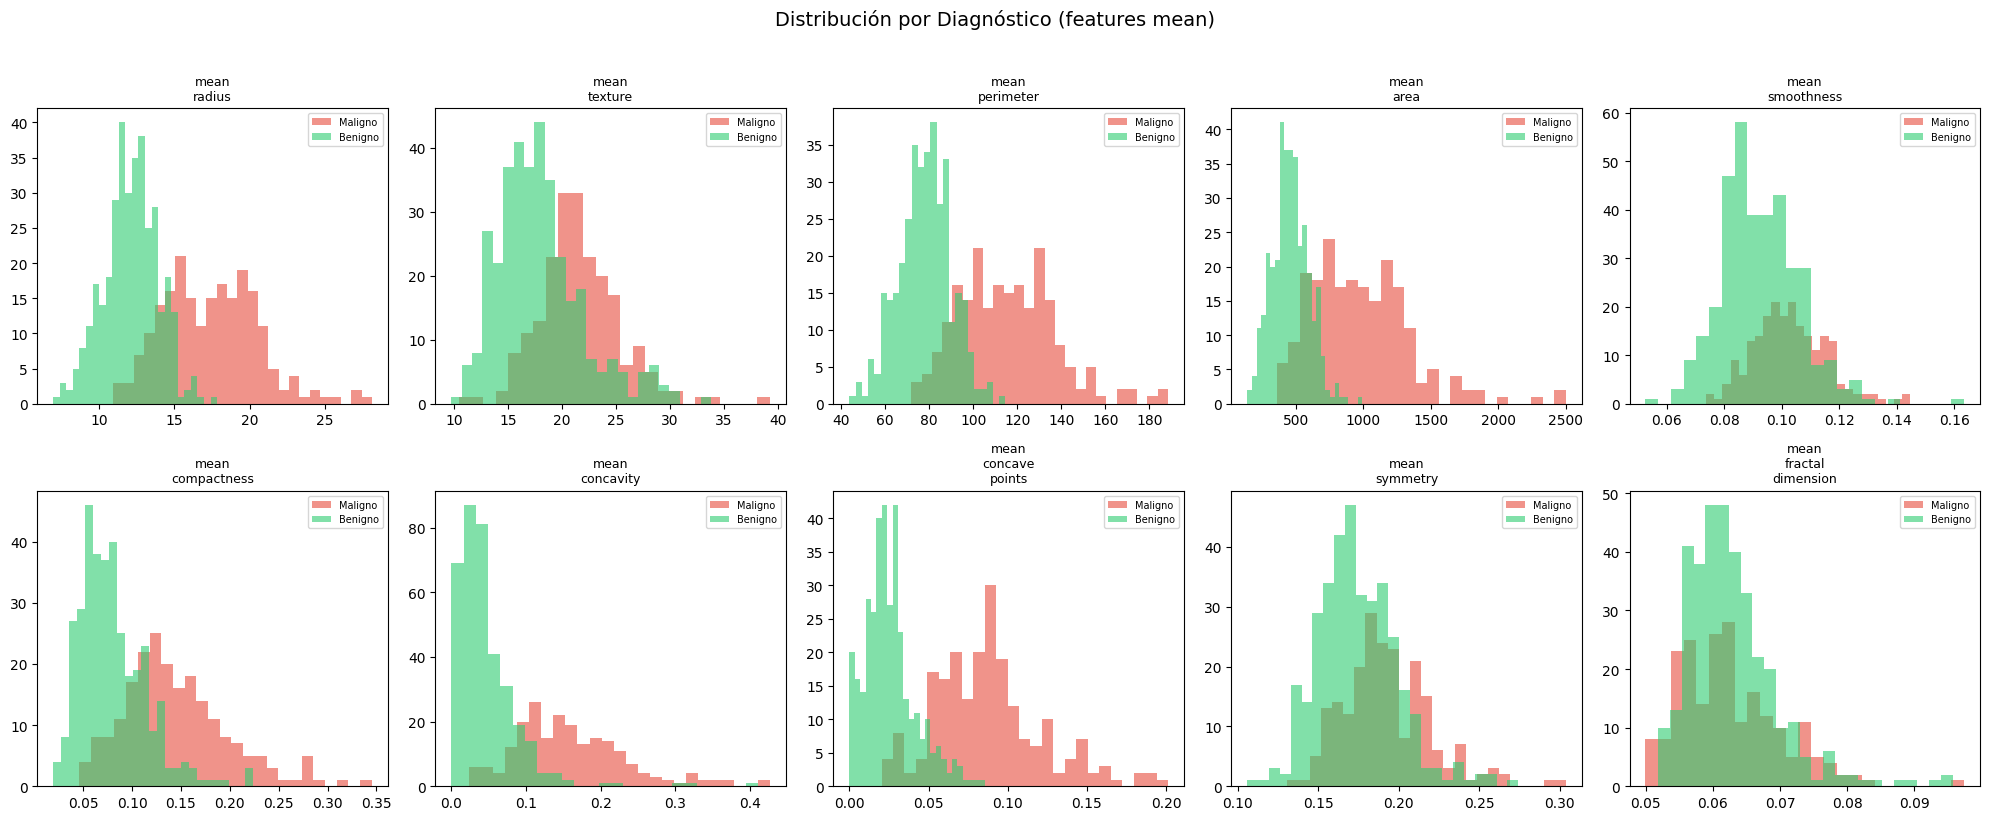

In [ ]:
# Histogramas de las caracteristicas "mean"
feats_mean = [col for col in df.columns if 'mean' in col]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, feat in enumerate(feats_mean):
    axes[i].hist(df[df['diagnosis'] == 0][feat], bins=25, alpha=0.6, label='Maligno', color='#e74c3c')
    axes[i].hist(df[df['diagnosis'] == 1][feat], bins=25, alpha=0.6, label='Benigno', color='#2ecc71')
    axes[i].set_title(feat.replace(' ', '\n'), fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución por Diagnóstico (features mean)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Graficamos las 10 features de tipo "mean" separadas por diagnóstico para ver cuáles separan bien las dos clases y cuáles no tanto.

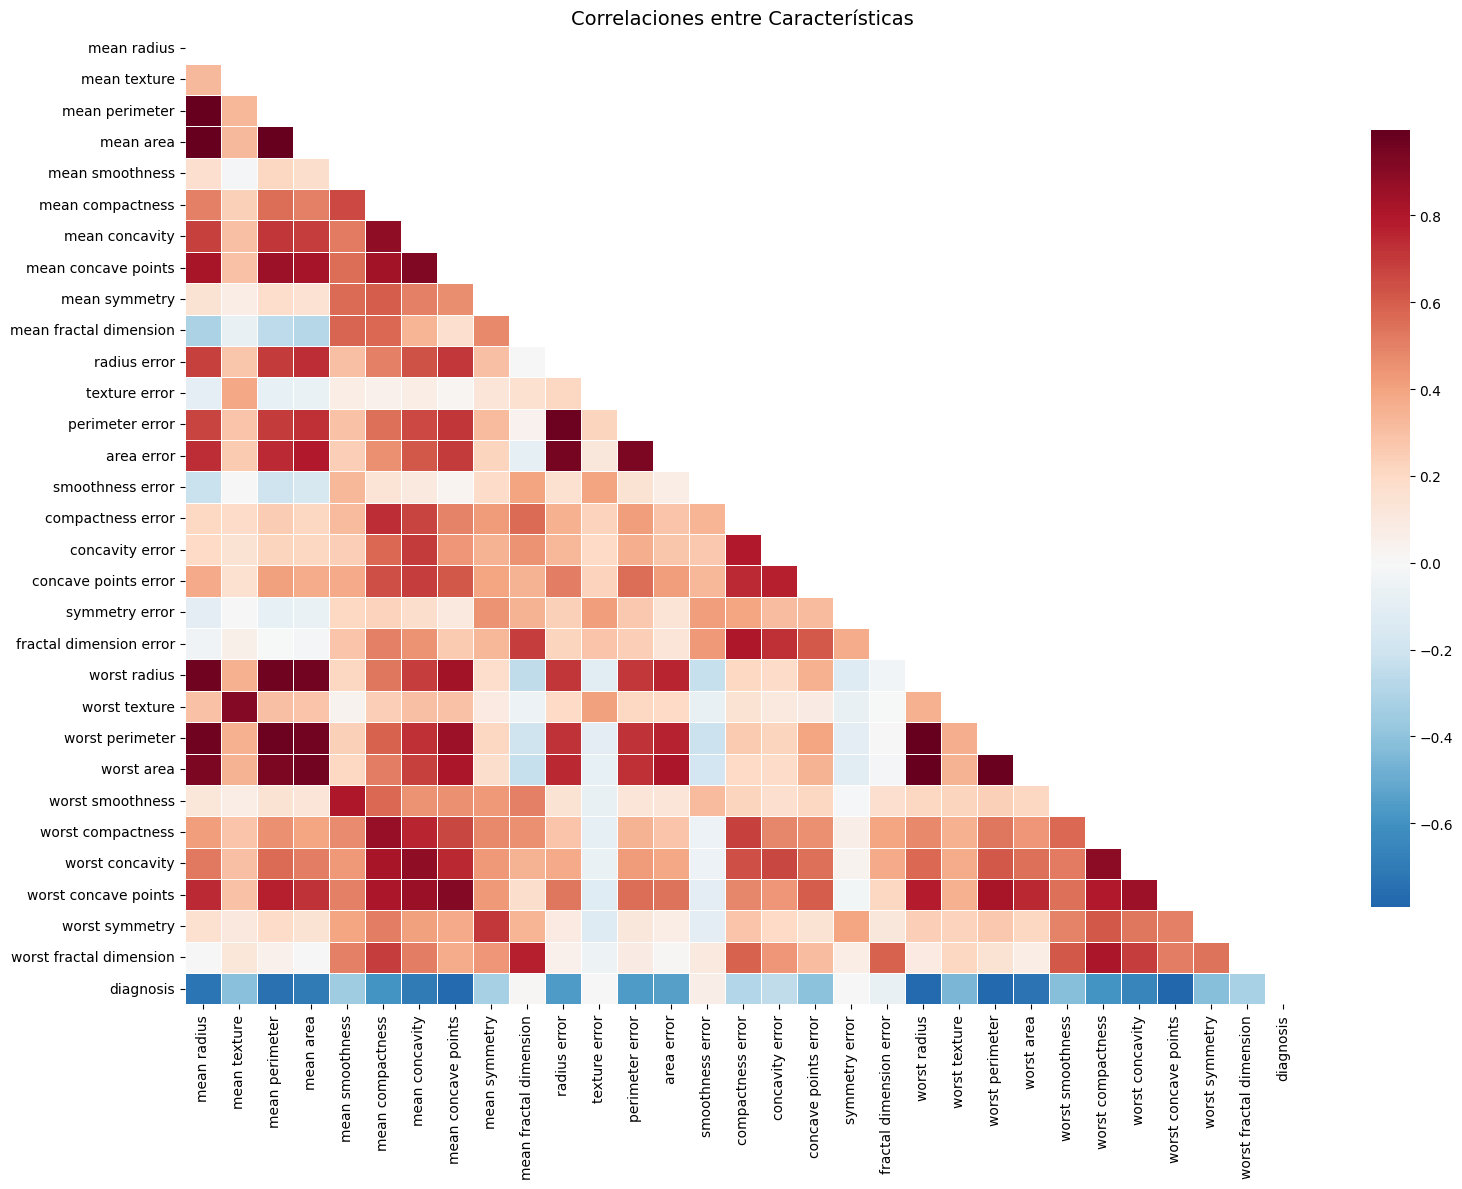

In [ ]:
# Heatmap de correlaciones
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlaciones entre Características', fontsize=14)
plt.tight_layout()
plt.show()

Con el heatmap vemos qué features están correlacionadas entre sí. Si hay muchas correlaciones altas significa que hay información redundante y PCA puede ayudar a comprimirla.

In [ ]:
# Features mas correlacionadas con el diagnostico
corr_target = corr['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print("Top 10 correlaciones positivas (benigno):")
print(corr_target.head(10).to_string())
print("\nTop 10 correlaciones negativas (maligno):")
print(corr_target.tail(10).to_string())

Top 10 correlaciones positivas (benigno):
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560

Top 10 correlaciones negativas (maligno):
worst concavity        -0.659610
mean concavity         -0.696360
mean area              -0.708984
mean radius            -0.730029
worst area             -0.733825
mean perimeter         -0.742636
worst radius           -0.776454
mean concave points    -0.776614
worst perimeter        -0.782914
worst concave points   -0.793566


Vemos cuáles son las features que más se relacionan con que un tumor sea maligno o benigno. Esto nos da una idea de qué variables son las más importantes para la clasificación.

In [ ]:
# Separar features y target
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

# Split: 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# Estandarizar (fit solo en train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

Train: 341, Val: 114, Test: 114


Separamos los datos en train, validación y test (60/20/20) y estandarizamos. Después calculamos la matriz de covarianza y sacamos los autovalores para preparar PCA.

In [ ]:
# Matriz de covarianza
cov_matrix = np.cov(X_train_s.T)
print("Matriz de covarianza calculada.")

# Autovalores y autovectores
eigen_vals, eigen_vecs = np.linalg.eig(cov_matrix)
print("Autovalores encontrados:", eigen_vals)


Matriz de covarianza calculada.
Autovalores encontrados: [1.33129163e+01 5.88384619e+00 2.80337634e+00 2.01197805e+00
 1.71691522e+00 1.13005648e+00 6.46725224e-01 4.75570318e-01
 3.94526631e-01 3.78279502e-01 2.59704296e-01 2.44638523e-01
 2.09556446e-01 1.57036838e-01 9.79237898e-02 7.27499076e-02
 5.96981225e-02 5.28634945e-02 3.69382724e-02 2.99153009e-02
 2.66859380e-02 2.49276603e-02 1.27895822e-04 6.28315610e-04
 1.50417389e-03 5.78314547e-03 7.36461994e-03 1.67982887e-02
 1.57963919e-02 1.34036569e-02]


Aplicamos PCA a los datos estandarizados y vemos qué porcentaje de la información original se quedó en cada componente.

In [ ]:
# creamos el modelo de pca
pca_modelo = PCA()
X_train_pca_total = pca_modelo.fit_transform(X_train_s)
X_val_pca_total = pca_modelo.transform(X_val_s)
X_test_pca_total = pca_modelo.transform(X_test_s)

# sacamos el porcentaje de info de cada uno
varianza = pca_modelo.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

print("paso pca: ya calculamos los componentes y esto es lo que explican:")
for i, v in enumerate(varianza):
    print(f"el componente {i+1} contiene el {v*100:.2f}% de la info")


paso pca: ya calculamos los componentes y esto es lo que explican:
el componente 1 contiene el 44.25% de la info
el componente 2 contiene el 19.56% de la info
el componente 3 contiene el 9.32% de la info
el componente 4 contiene el 6.69% de la info
el componente 5 contiene el 5.71% de la info
el componente 6 contiene el 3.76% de la info
el componente 7 contiene el 2.15% de la info
el componente 8 contiene el 1.58% de la info
el componente 9 contiene el 1.31% de la info
el componente 10 contiene el 1.26% de la info
el componente 11 contiene el 0.86% de la info
el componente 12 contiene el 0.81% de la info
el componente 13 contiene el 0.70% de la info
el componente 14 contiene el 0.52% de la info
el componente 15 contiene el 0.33% de la info
el componente 16 contiene el 0.24% de la info
el componente 17 contiene el 0.20% de la info
el componente 18 contiene el 0.18% de la info
el componente 19 contiene el 0.12% de la info
el componente 20 contiene el 0.10% de la info
el componente 21 con

Graficamos la varianza explicada por cada componente para decidir cuántos conservar. Buscamos el punto donde ya no vale la pena agregar más.

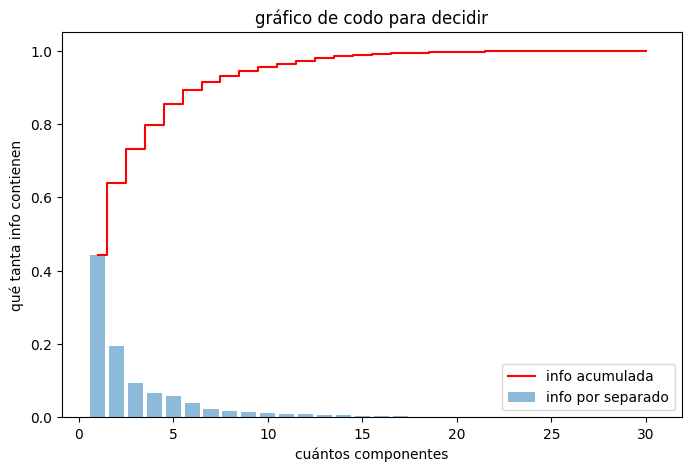

paso pca: graficar


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza) + 1), varianza, alpha=0.5, label='info por separado')
plt.step(range(1, len(varianza_acum) + 1), varianza_acum, where='mid', label='info acumulada', color='red')
plt.xlabel('cuántos componentes')
plt.ylabel('qué tanta info contienen')
plt.title('gráfico de codo para decidir')
plt.legend()
plt.show()

print("paso pca: graficar")


Nos quedamos con 8 componentes principales. Así pasamos de 30 features a solo 8, conservando la mayor parte de la información.

In [ ]:
n_componentes = 8

X_train_pca = X_train_pca_total[:, :n_componentes]
X_val_pca = X_val_pca_total[:, :n_componentes]
X_test_pca = X_test_pca_total[:, :n_componentes]

print(f"Train PCA: {X_train_pca.shape}")
print(f"Val PCA: {X_val_pca.shape}")
print(f"Test PCA: {X_test_pca.shape}")


Train PCA: (341, 8)
Val PCA: (114, 8)
Test PCA: (114, 8)


In [ ]:
# Modelo de una sola neurona (sigmoide)
lr = 0.001
epocas = 100
batch = 32

modelo = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(X_train_s.shape[1],))
])
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Creamos una red con una sola neurona y activación sigmoide. Usamos Adam como optimizador y binary crossentropy como función de pérdida, ya que es un problema de clasificación binaria.

In [ ]:
# Entrenar
historial = modelo.fit(
    X_train_s, y_train,
    epochs=epocas,
    batch_size=batch,
    validation_data=(X_val_s, y_val),
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1822 - loss: 1.3592 - val_accuracy: 0.1579 - val_loss: 1.2638
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2058 - loss: 1.2455 - val_accuracy: 0.2281 - val_loss: 1.1640
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2459 - loss: 1.1389 - val_accuracy: 0.2719 - val_loss: 1.0711
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2997 - loss: 1.0398 - val_accuracy: 0.3421 - val_loss: 0.9858
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3585 - loss: 0.9491 - val_accuracy: 0.4123 - val_loss: 0.9083
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4166 - loss: 0.8673 - val_accuracy: 0.4561 - val_loss: 0.8386
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4776 - loss: 0.7943 - val_accuracy: 0.5000 - val_loss: 0.7762
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5565 - loss: 0.7298 - val_accuracy: 0.5526 - 

Entrenamos por 100 épocas con batch de 32. Usamos el set de validación para ir viendo que no se sobreajuste.

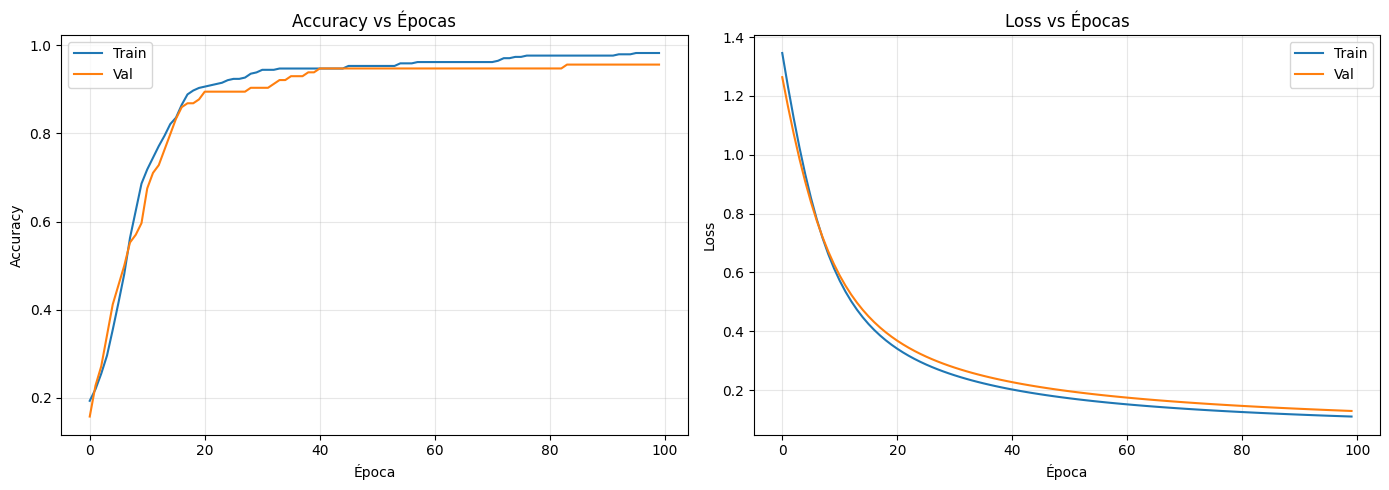

In [ ]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial.history['accuracy'], label='Train')
axes[0].plot(historial.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy vs Épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial.history['loss'], label='Train')
axes[1].plot(historial.history['val_loss'], label='Val')
axes[1].set_title('Loss vs Épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Graficamos el accuracy y el loss durante el entrenamiento. Si las curvas de train y validación se parecen, el modelo generaliza bien.

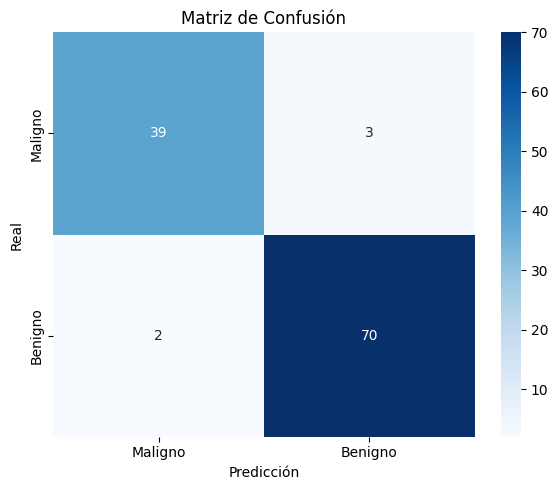

Accuracy:      0.9561
Precision:     0.9589
Recall:        0.9722
Especificidad: 0.9286
F1-score:      0.9655


In [ ]:
# Evaluacion en test
y_pred_prob = modelo.predict(X_test_s, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

mc = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = mc.ravel()

# Metricas
accuracy = (vp + vn) / (vp + vn + fp + fn)
precision = vp / (vp + fp)
recall = vp / (vp + fn)
especificidad = vn / (vn + fp)
f1 = 2 * precision * recall / (precision + recall)

# Matriz de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(mc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"F1-score:      {f1:.4f}")

Evaluamos el modelo con datos que nunca vio. Sacamos la matriz de confusión y las métricas: accuracy, precision, recall, especificidad y F1.

In [ ]:
# Guardar modelo
modelo.save('neurona_unica_original.keras')
print("Modelo guardado")

# Verificar que carga bien
modelo_cargado = keras.models.load_model('neurona_unica_original.keras')
loss, acc = modelo_cargado.evaluate(X_test_s, y_test, verbose=0)
print(f"Modelo cargado - Loss: {loss:.4f}, Acc: {acc:.4f}")

Modelo guardado
Modelo cargado - Loss: 0.1352, Acc: 0.9561


Ahora hacemos lo mismo pero con los datos reducidos por PCA. Usamos la misma arquitectura de una sola neurona para comparar.

In [ ]:
modelo_pca = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(X_train_pca.shape[1],))
])
modelo_pca.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo_pca.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar modelo con PCA
historial_pca = modelo_pca.fit(
    X_train_pca, y_train,
    epochs=epocas,
    batch_size=batch,
    validation_data=(X_val_pca, y_val),
    verbose=1
)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4959 - loss: 0.9075 - val_accuracy: 0.5175 - val_loss: 0.8956
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5078 - loss: 0.8835 - val_accuracy: 0.5263 - val_loss: 0.8748
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5129 - loss: 0.8603 - val_accuracy: 0.5439 - val_loss: 0.8544
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5189 - loss: 0.8375 - val_accuracy: 0.5439 - val_loss: 0.8343
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5338 - loss: 0.8153 - val_accuracy: 0.5526 - val_loss: 0.8148
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5417 - loss: 0.7936 - val_accuracy: 0.5702 - val_loss: 0.7956
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5664 - loss: 0.7725 - val_accuracy: 0.5702 - val_loss: 0.7770
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5691 - loss: 0.7520 - val_accuracy: 0.5877 - 

Entrenamos con los mismos hiperparámetros (100 épocas, batch 32, lr 0.001) pero ahora la entrada tiene solo 8 features en vez de 30.

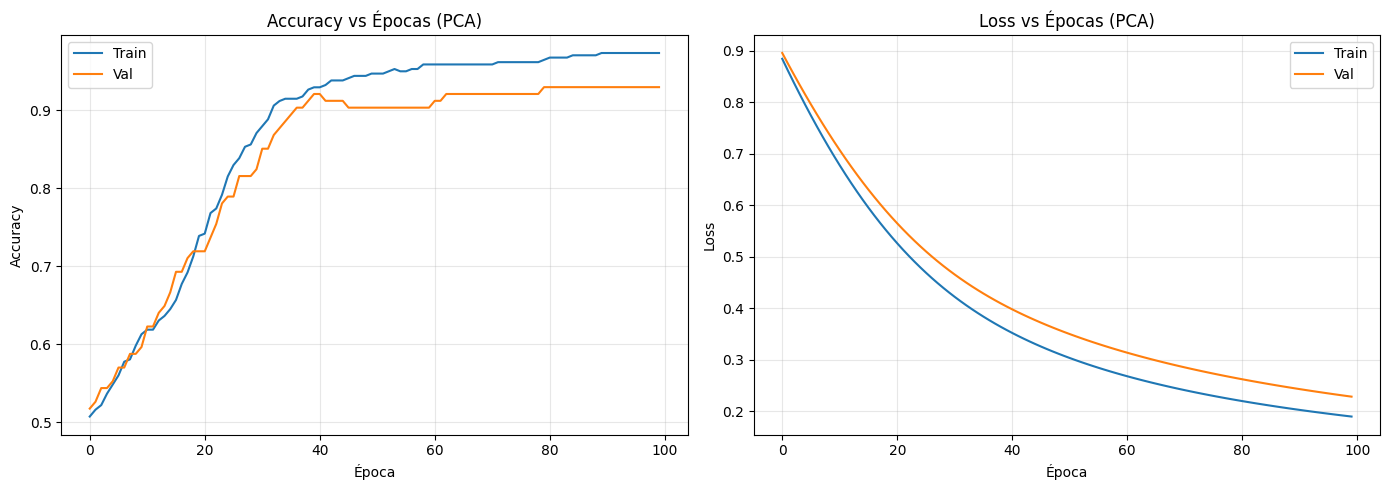

In [ ]:
# Curvas de aprendizaje del modelo con PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial_pca.history['accuracy'], label='Train')
axes[0].plot(historial_pca.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy vs Épocas (PCA)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial_pca.history['loss'], label='Train')
axes[1].plot(historial_pca.history['val_loss'], label='Val')
axes[1].set_title('Loss vs Épocas (PCA)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Vemos cómo se comportó el entrenamiento del modelo con PCA. Comparamos si converge igual de bien que el original.

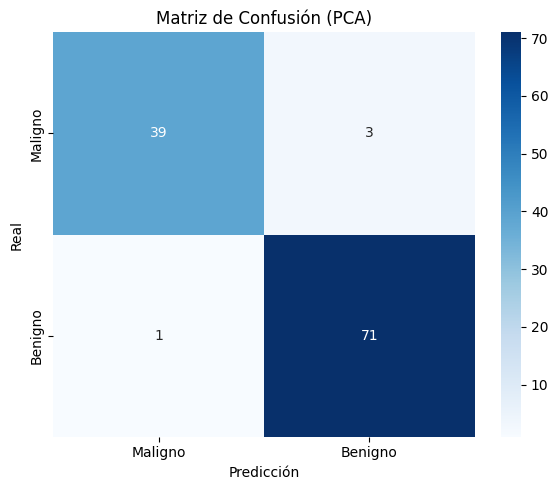

Accuracy PCA:      0.9649
Precision PCA:     0.9595
Recall PCA:        0.9861
Especificidad PCA: 0.9286
F1-score PCA:      0.9726


In [ ]:
# Evaluacion en test del modelo con PCA
y_pred_prob_pca = modelo_pca.predict(X_test_pca, verbose=0)
y_pred_pca = (y_pred_prob_pca >= 0.5).astype(int).flatten()

mc_pca = confusion_matrix(y_test, y_pred_pca)
vn_pca, fp_pca, fn_pca, vp_pca = mc_pca.ravel()

accuracy_pca = (vp_pca + vn_pca) / (vp_pca + vn_pca + fp_pca + fn_pca)
precision_pca = vp_pca / (vp_pca + fp_pca)
recall_pca = vp_pca / (vp_pca + fn_pca)
especificidad_pca = vn_pca / (vn_pca + fp_pca)
f1_pca = 2 * precision_pca * recall_pca / (precision_pca + recall_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(mc_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.title('Matriz de Confusión (PCA)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"Accuracy PCA:      {accuracy_pca:.4f}")
print(f"Precision PCA:     {precision_pca:.4f}")
print(f"Recall PCA:        {recall_pca:.4f}")
print(f"Especificidad PCA: {especificidad_pca:.4f}")
print(f"F1-score PCA:      {f1_pca:.4f}")


Comparamos los resultados del modelo original contra el modelo con PCA para ver si la reducción de dimensionalidad afectó el rendimiento.

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['Una neurona sin PCA', 'Una neurona con PCA'],
    'Accuracy': [accuracy, accuracy_pca],
    'Precision': [precision, precision_pca],
    'Recall': [recall, recall_pca],
    'Especificidad': [especificidad, especificidad_pca],
    'F1-score': [f1, f1_pca]
})

print(comparacion)


                Modelo  Accuracy  Precision    Recall  Especificidad  F1-score
0  Una neurona sin PCA  0.956140   0.958904  0.972222       0.928571  0.965517
1  Una neurona con PCA  0.964912   0.959459  0.986111       0.928571  0.972603


In [ ]:
# Guardar modelo con PCA
modelo_pca.save('neurona_unica_pca.keras')
print("Modelo con PCA guardado")

modelo_pca_cargado = keras.models.load_model('neurona_unica_pca.keras')
loss_pca, acc_pca = modelo_pca_cargado.evaluate(X_test_pca, y_test, verbose=0)
print(f"Modelo PCA cargado - Loss: {loss_pca:.4f}, Acc: {acc_pca:.4f}")


Modelo con PCA guardado
Modelo PCA cargado - Loss: 0.2139, Acc: 0.9649


Guardamos el modelo con PCA para tenerlo disponible sin tener que reentrenar.

**Conclusiones**

*Ignacio*

A partir de esta actividad se comprendió mejor cómo funciona la reducción de dimensionalidad mediante PCA y su aplicación antes de entrenar un modelo de clasificación. Se pudo observar que un modelo de una sola neurona puede trabajar tanto con todas las características originales del dataset como con un número reducido de componentes principales, manteniendo un desempeño similar. Esto permitió entender cómo PCA conserva la mayor parte de la información del conjunto de datos a través de la varianza explicada, mientras simplifica el problema al reducir el número de variables.

Las principales dificultades estuvieron relacionadas con la interpretación de los resultados después de aplicar PCA y con determinar cuántos componentes principales eran suficientes para mantener la mayor parte de la información del dataset. Se resolvió comparando el desempeño del modelo entrenado con las características originales contra el modelo entrenado con los componentes principales obtenidos por PCA.

Repositorio Personal Github: https://github.com/GaxCor/Single-Neuron-Network-with-and-without-PCA.git

*Cesar*

En esta actividad vimos el desempeño de una red neuronal de una sola neurona, donde la aplicamos al dataset de Breast Cancer de Wisconsin. Comparamos los resultados entre el modelo con el dataset original y después de aplicar PCA.

De los principales aprendizajes fue que entendimos cómo el PCA puede afectar cómo se comporta el modelo. Se vio que al transformar con PCA el modelo tiene diferencias en su rendimiento que con el modelo sin PCA. Esto muestra que el PCA puede reducir la dimensionalidad y quitar redundancia incluso en un modelo de una sola neurona.

Se aprendió que al construir y entrenar un modelo se puede evaluar su desempeño en una tarea de clasificación y se vio que un modelo simple de una neurona puede lograr un rendimiento aceptable, y que el modelo se puede entrenar con datos originales o con PCA.

De las dificultades fue interpretar los datos, ya que surgió la duda de por qué los datos no eran iguales en cada ejecución con y sin PCA. Se vio que al entrenar los dos modelos en las mismas condiciones y comparar sus resultados, estas variaciones pueden ser por el proceso de entrenamiento y dependiendo de dónde se corra el modelo.

Se menciona que el modelo fue muy simple, lo cual limita su capacidad al tener solo una neurona. Se ocuparía una arquitectura con más capas o más neuronas (que lo veremos más adelante en el curso) para poder ver realmente su rendimiento, así como ajustar hiperparámetros.

Este ejercicio me permitió comprender más el impacto del PCA y cómo poder implementar modelos de una sola neurona en un dataset.

Repositorio Personal Github: https://github.com/Cesardlr/tarea4-IA2-cesardelrio-634582.git

*Leonardo*

Si bien en la actividad pasada se exploró la reducción de dimensionalidad en un dataset para facilitar el procesamiento de datos, en esta ocasión se comparó la eficiencia del PCA contra la forma “normal”, es decir, entrenando el modelo con todas las variables del dataset.

Los resultados mostraron que el modelo con PCA obtuvo métricas muy similares al entrenamiento tradicional, lo cual indica que es posible reducir el número de características sin afectar de forma significativa el desempeño del modelo. Esto es relevante porque PCA permite concentrar la información más importante de los datos, eliminando redundancia entre variables y reduciendo el costo computacional del entrenamiento, lo cual toma más valor en modelos o datasets más grandes.

Una limitación que se observó fue que en algunas ocasiones la prueba con PCA no producía exactamente los mismos resultados entre ejecuciones. Esto puede deberse a factores técnicos como la inicialización aleatoria de pesos, diferencias en versiones de librerías o el hecho de que ciertas operaciones cuando se ejecutan en GPU no siempre son completamente deterministas.

Aun así, en términos generales el desempeño obtenido con PCA se mantuvo muy cercano al del enfoque tradicional, lo que confirma que sigue siendo una técnica efectiva para reducir dimensionalidad sin perder capacidad de clasificación.

Repositorio Personal Github: https://github.com/LeoTG03/04-SingleNeuron-with-and-without-PCA.git